In [ ]:
import os
import re
from io import StringIO
from pathlib import Path

import scanpy as sc
import anndata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import networkx as nx
import math
import seaborn as sns


mpl.rcParams['figure.dpi'] = 200

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


In [ ]:
sd_distance = '../../../data/GBM_LEAP_annotations/cell2location/distances/'
distance_comparison = pd.read_csv(sd_distance+'distances_niches_coarse_ivy_p75.csv')

# Network plot

In [ ]:
def nudge(pos, x_shift, y_shift):
    return {n:(x + x_shift, y + y_shift) for n,(x,y) in pos.items()}

In [ ]:
savedir = '../../../data/GBM_LEAP_annotations/cell2location/distances/'

# bottom 25th percentile of nearest neighbour distances per section (closest spots)
proximity_threshold = distance_comparison.groupby(['donor_id', 'sample', 'clusterA', 'clusterB'], 
                            as_index=False)['distance'].quantile(0.25)\
                                .rename(columns={'distance':'proximity_threshold'})
distance_comparison = distance_comparison.merge(proximity_threshold, on = ['donor_id', 'sample', 'clusterA', 'clusterB'])
distance_comparison = distance_comparison[distance_comparison['distance']<=distance_comparison['proximity_threshold']]

In [ ]:
# prep analysis
median_distances = distance_comparison.groupby(['donor_id', 
                                                'sample',
                                                'clusterA', 
                                                'clusterB'], 
                                               as_index=False)['distance'].median()

In [ ]:
# mean the distances in either direction
median_distances['clusters'] = median_distances[['clusterA', 'clusterB']].apply(
    lambda row: str(sorted([row["clusterA"], row["clusterB"]])), axis=1)

median_distances["clusters"] = median_distances["clusters"].str.strip("[]").str.replace("'", "")
median_distances[["clusterA", "clusterB"]] = median_distances["clusters"].str.split(", ", expand=True)
median_distances = median_distances.sort_values('distance').reset_index(drop=True)

In [ ]:
# Get medians
median_distances = median_distances.groupby(['clusterA', 'clusterB', 'clusters'], 
                                            as_index=False)['distance'].agg(['mean', 'std'])

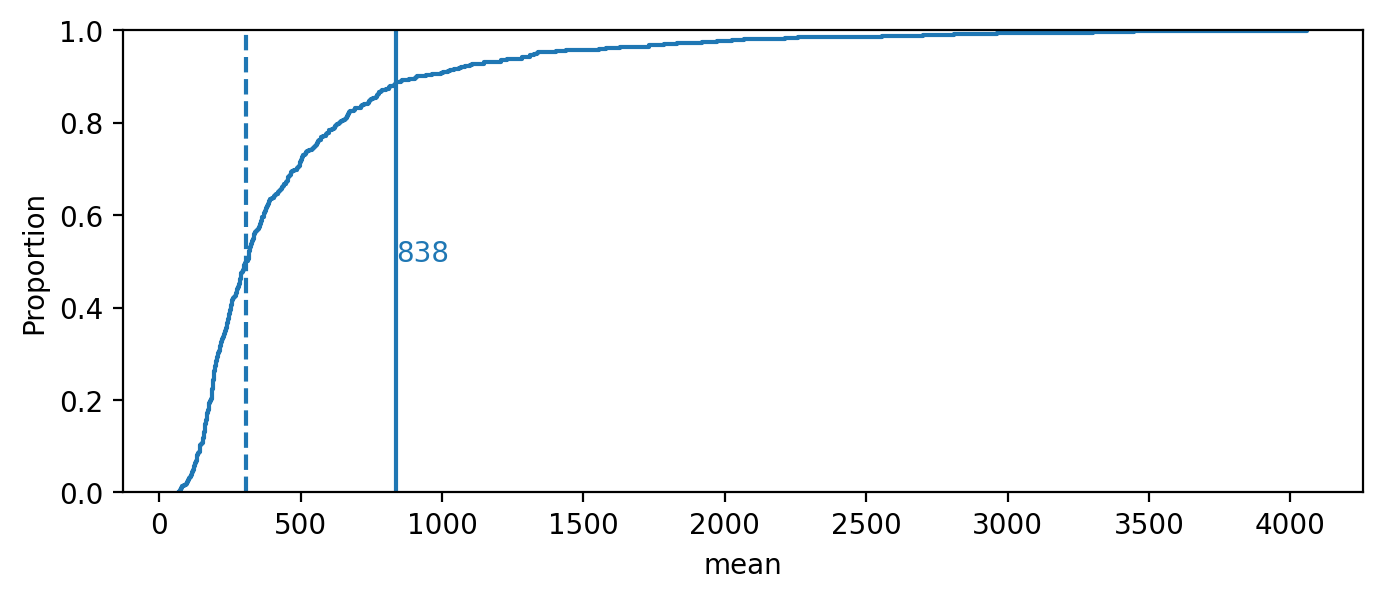

In [ ]:
from kneed import KneeLocator

def ecdf_knee_simple(values):
    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x)

    # line between endpoints
    x0, y0 = x[0], y[0]
    x1, y1 = x[-1], y[-1]

    # distance from each point to the line
    num = np.abs((y1 - y0)*x - (x1 - x0)*y + x1*y0 - y1*x0)
    den = np.sqrt((y1 - y0)**2 + (x1 - x0)**2)

    distances = num / den
    return x[np.argmax(distances)]

knee_value = ecdf_knee_simple(median_distances['mean'])

fig, ax = plt.subplots(figsize=(8,3))


sns.ecdfplot(data=median_distances, x="mean")
plt.axvline(knee_value)
plt.axvline(median_distances['mean'].quantile(0.5), linestyle = '--')

plt.text(x = knee_value+0.5, y = 0.5, s = round(knee_value), color = '#1f77b4')

plt.show()

In [ ]:
# get plotting df - only plot the most relevant connections to ensure plot is not too busy
df = median_distances[median_distances['mean']<median_distances['mean'].quantile(0.5)].copy()

In [ ]:
pos = {
    "Pial layer": (0, 5),
    "Dev-like (OPC)": (1, 4),
    "Dev-like (AC)": (2, 4),
    "Proliferative": (3, 4),
    "White matter": (0, 3),
    "Immune (resident)": (1, 2),
    "Immune (infiltrating)": (2, 2),
    "Vasculature": (3, 2),
    "Gliosis transition": (4, 3),
    "Gliosis": (5, 3),
    "Hypoxic 1 (niche)": (6, 3),
    "Grey matter": (0, 1),
}

node_colors_dict = {
    "Pial layer": "#cccccc",
    "Dev-like (OPC)": "#F8BF85",
    "Dev-like (AC)": "#eebe4c",
    "Proliferative": "#f0e443",
    "White matter": "#5d3393",
    "Immune (resident)": "#4a72b8",
    "Immune (infiltrating)": "#8d574c",
    "Vasculature": "#059e74",
    "Gliosis transition": "#b11f65",
    "Gliosis": "#d46127",
    "Hypoxic 1 (niche)": "#666666",
    "Grey matter": "#5bb4e5",
}

In [ ]:
weighting = 'inverse'



# weighting method
if weighting == 'inverse':
    df['weight'] = 1/df['mean']
    df['weight'] = df['weight']*900
    df['weight'] = np.where(df['weight']>df['weight'].quantile(0.9), 
                            df['weight'].quantile(0.9), df['weight'])
elif weighting=='minmax':
    df['weight'] = df['mean'].max()-df['mean']
    df['weight'] = df['weight']/100

#

df['clusterA'] = np.where(df['clusterA']=='Immune (TAMs)', 'Immune (infiltrating)', df['clusterA'])
df['clusterB'] = np.where(df['clusterB']=='Immune (TAMs)', 'Immune (infiltrating)', df['clusterB'])
df = df[(df['clusterA'].isin(pos.keys())) & (df['clusterB'].isin(pos.keys()))]

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/networkx/drawing/nx_pylab.py:457: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  node_collection = ax.scatter(


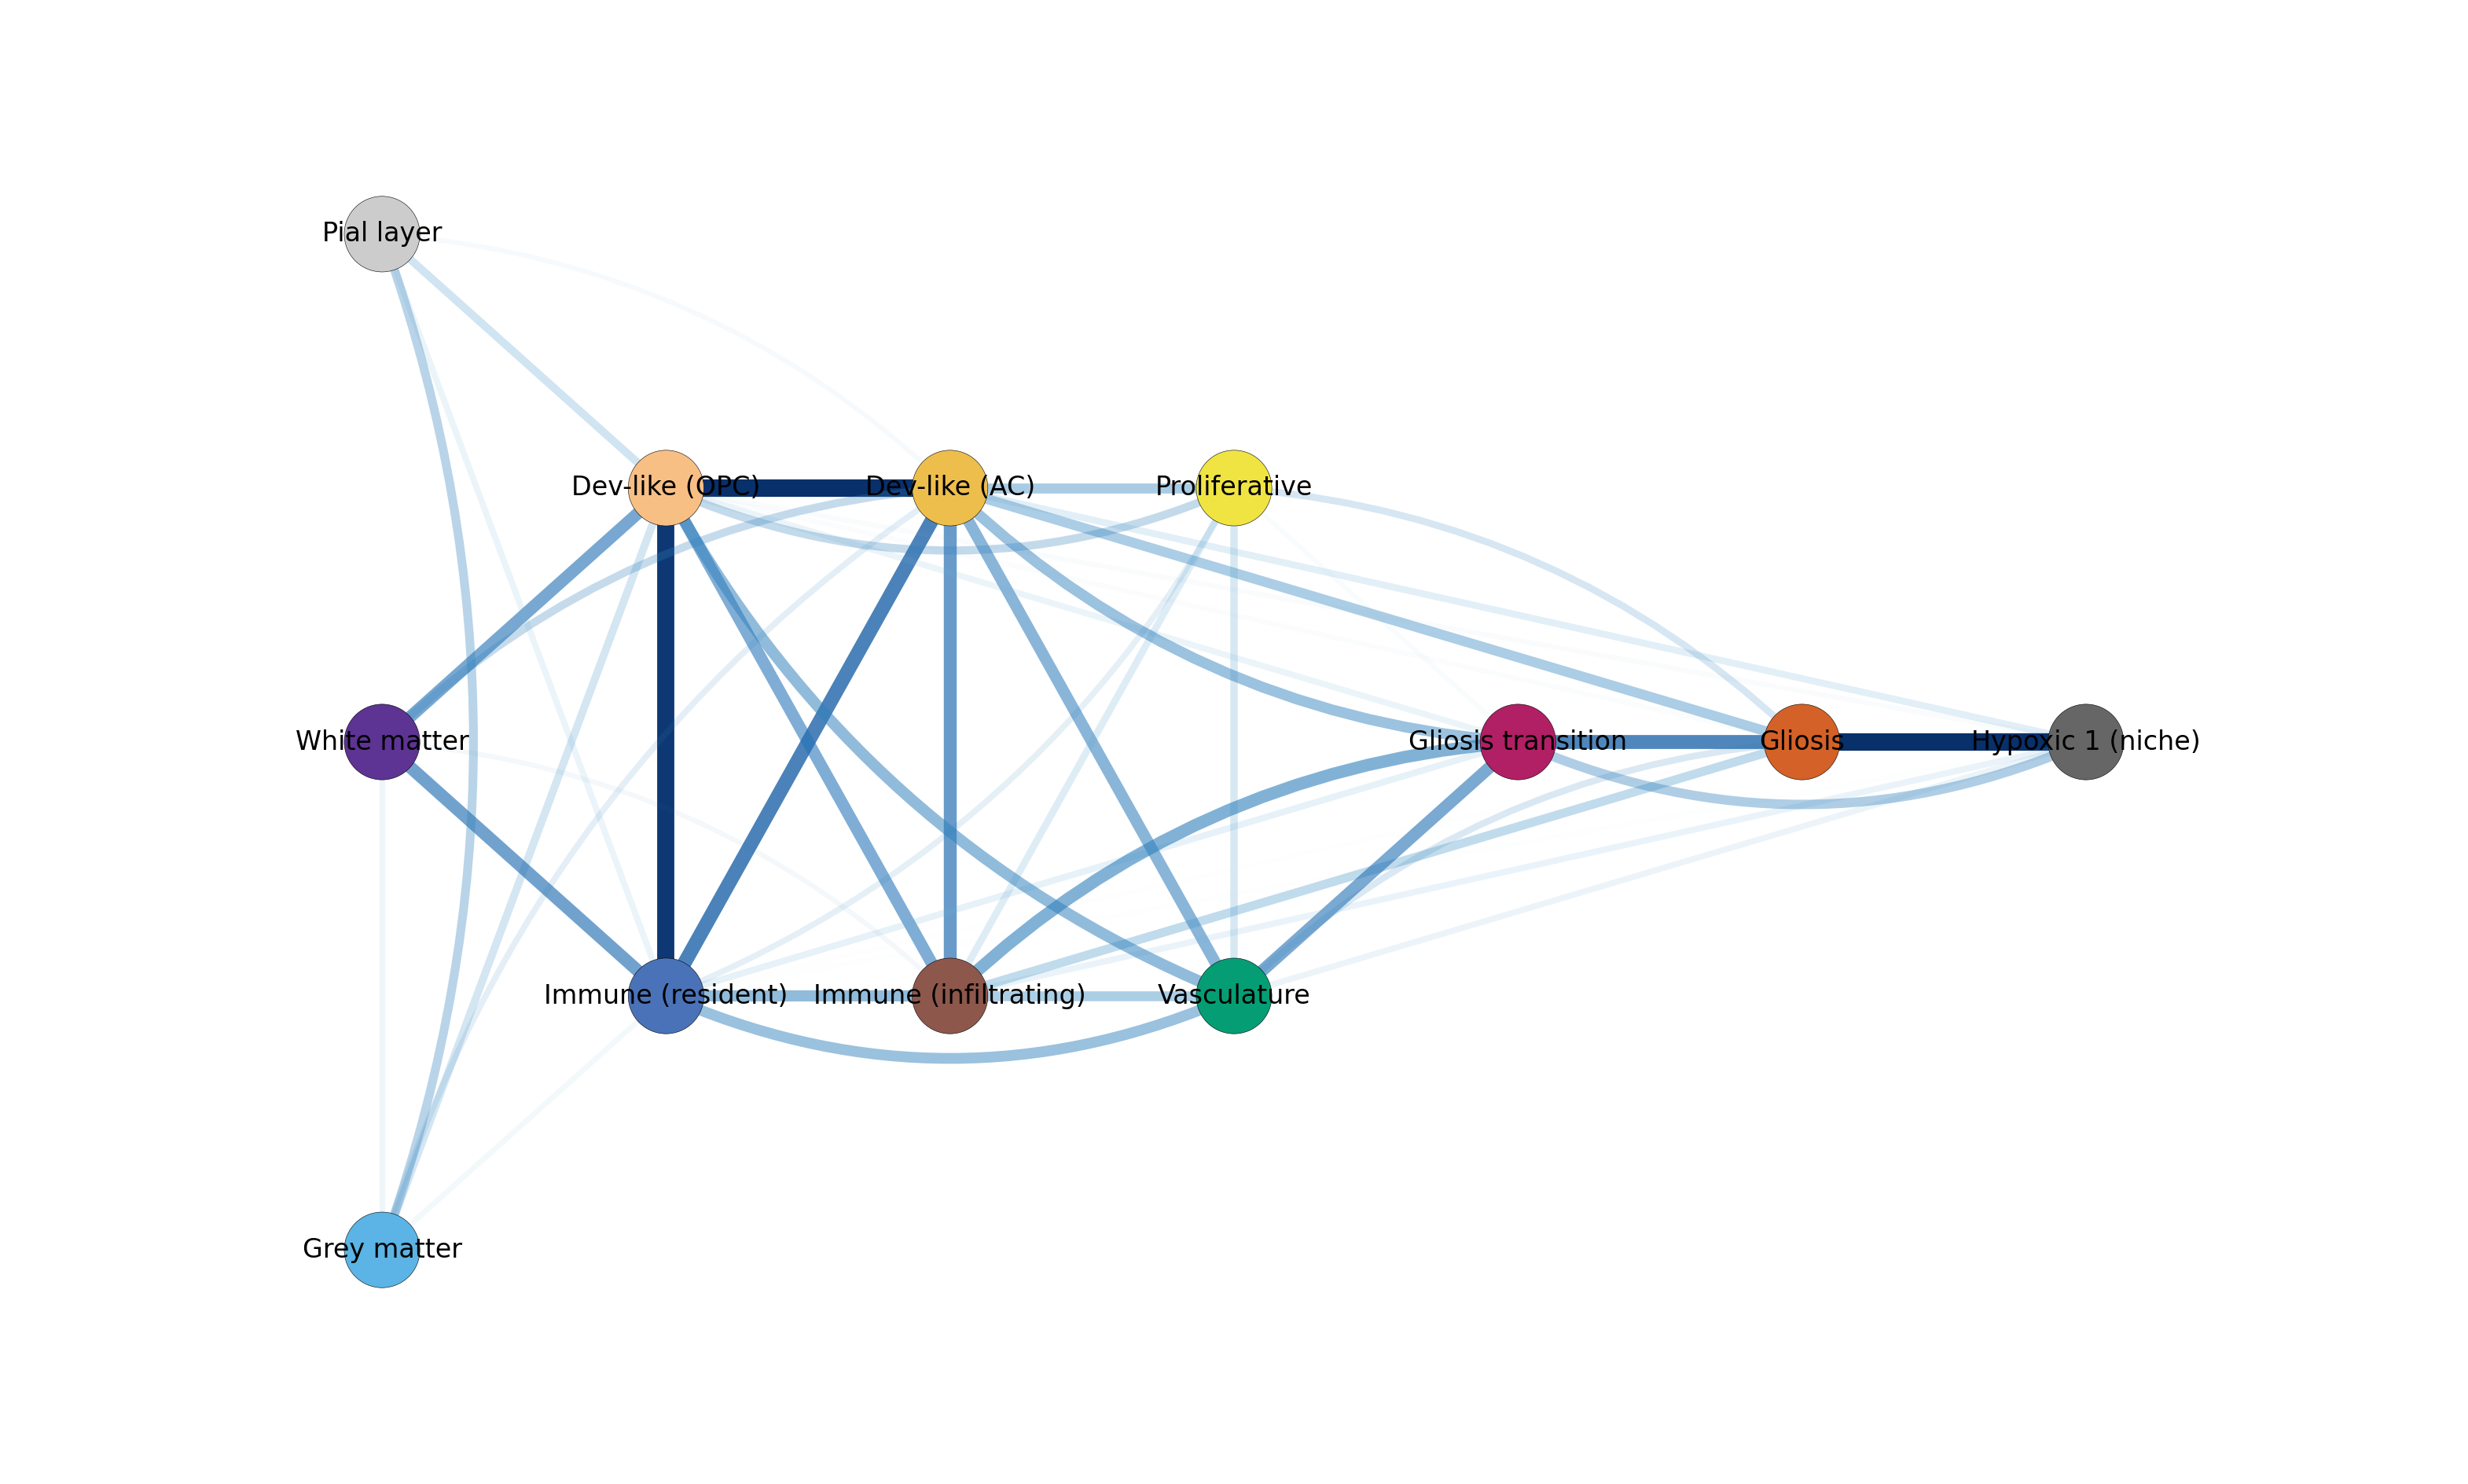

In [ ]:
#distance_col = '1-min_max_dist'
#distance_col = 'inv_distance'
distance_col = 'weight'


G = nx.from_pandas_edgelist(
    df,
    source="clusterA",
    target="clusterB",
    edge_attr=distance_col,
    create_using=nx.Graph()
)

nx.set_edge_attributes(
    G,
    {(u, v): d[distance_col] for u, v, d in G.edges(data=True)},
    name="weight"
)

# ---- manual 2x2 layout ----
nodes = list(G.nodes())

# extract distances
distances = [d[distance_col] for _, _, d in G.edges(data=True)]


# --- rescale edge widths to a new range ---
min_w, max_w = 2, 8   # change these

distances = [d["weight"] for _, _, d in G.edges(data=True)]

d_min, d_max = min(distances), max(distances)
widths = [
    min_w + (d - d_min) / (d_max - d_min) * (max_w - min_w)
    if d_max > d_min else min_w
    for d in distances
]

fig, ax = plt.subplots(figsize=(20, 12))

min_a, max_a = 0, 1.0
alphas = [
    min_a + (d - d_min) / (d_max - d_min) * (max_a - min_a)
    if d_max > d_min else min_a
    for d in distances
]
straight_edges, curved_edges = [], []
straight_widths, curved_widths = [], []
straight_colors, curved_colors = [], []
straight_alphas, curved_alphas = [], []

for (u, v, d), w, a in zip(G.edges(data=True), widths, alphas):
    col_gap = abs(pos[u][0] - pos[v][0])
    row_gap = abs(pos[u][1] - pos[v][1])

    # curve if separated by one vertical step, or by two horizontal steps
    if col_gap == 2 or row_gap == 4:
        curved_edges.append((u, v))
        curved_widths.append(w)
        curved_colors.append(d["weight"])
        curved_alphas.append(a)
    else:
        straight_edges.append((u, v))
        straight_widths.append(w)
        straight_colors.append(d["weight"])
        straight_alphas.append(a)

norm = mcolors.Normalize(vmin=0, vmax=d_max)
cmap = cm.Blues



node_colors = [node_colors_dict[n] for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax, 
                       node_color=node_colors,
                       cmap=cm.Reds,
                       vmin = 0.5,
                       vmax = 1,
                       linewidths=0.2,
                       edgecolors="black",
                       node_size=1200)
nx.draw_networkx_labels(G, pos, ax=ax)

# draw all straight edges together
nx.draw_networkx_edges(
    G,
    pos,
    ax=ax,
    edgelist=straight_edges,
    width=straight_widths,
    edge_color=cmap(norm(straight_colors)),
    alpha = straight_alphas,
    #edge_cmap=cm.Blues,
    #edge_vmin= 0, #min(distances),
    #edge_vmax=max(distances),
)

# draw curved edges one at a time
for (u, v), w, c, a in zip(curved_edges, curved_widths, curved_colors, curved_alphas):
    y1 = pos[u][1]
    y2 = pos[v][1]

    if y1 == y2:
        rad = 0.22 if y1 > 0 else -0.22
    else:
        rad = 0.18

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        edgelist=[(u, v)],
        width=[w],
        edge_color=cmap(norm(curved_colors)),
        #edge_cmap=cm.Blues,
        #edge_vmin=0, #min(distances),
        #edge_vmax=max(distances),
        alpha=a,
        connectionstyle=f"arc3,rad={rad}",
        arrows=True,
        arrowstyle="-",
    )

ax.margins(0.15)
ax.set_axis_off()
plt.savefig('../data/distance_assessment/network.pdf')

In [ ]:
output_dir = '../../../data/Fig2/'
df.to_csv(os.path.join(output_dir, 'Fig2d_network_plot.csv'))